# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

### Step 1. Load the data


In [8]:
df = pd.read_csv(r"C:\Users\Renad\Downloads\bmi_and_life_expectancy.csv")

### Step 2.a Assign variables `X` to the features and `y` to the target

In [9]:
X = df[['BMI']]
y = df['Life expectancy']

### Step 2.b print the type of each

In [10]:
print(f"X type: {type(X)}, y type: {type(y)}")

X type: <class 'pandas.DataFrame'>, y type: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [11]:
if y.dtype == 'float64' or y.dtype == 'int64':
    print("Target is: Numerical (Continuous)")
    print("Task is: Regression")
else:
    print("Target is: Categorical")
    print("Task is: Classification")

Target is: Numerical (Continuous)
Task is: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [12]:
rows_X, cols_X = X.shape
rows_y = y.shape[0] 

print(f"Features (X) - Samples: {rows_X}, Columns: {cols_X}")
print(f"Target (y) - Samples: {rows_y}")

Features (X) - Samples: 163, Columns: 1
Target (y) - Samples: 163


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [13]:
summary = df.describe()
print(summary)

print("\nSpecific Statistics for BMI and Life Expectancy:")
print(df[['BMI', 'Life expectancy']].agg(['min', 'max', 'median', 'mean', 'std']))

       Life expectancy         BMI
count       163.000000  163.000000
mean         69.666933   24.792378
std           8.981933    2.427900
min          44.500000   19.866920
25%          63.450000   22.527940
50%          71.800000   25.320540
75%          76.500000   26.603960
max          84.600000   30.995630

Specific Statistics for BMI and Life Expectancy:
              BMI  Life expectancy
min     19.866920        44.500000
max     30.995630        84.600000
median  25.320540        71.800000
mean    24.792378        69.666933
std      2.427900         8.981933


### Step 5. Plot the feature vs the target

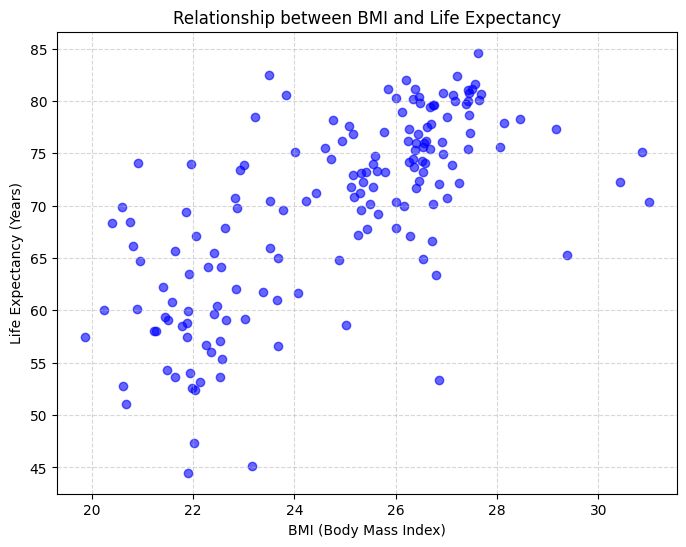

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.6)
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Life Expectancy (Years)')
plt.title('Relationship between BMI and Life Expectancy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [15]:
correlation = df['BMI'].corr(df['Life expectancy'])

if correlation > 0:
    relationship = "Increasing (Positive)"
elif correlation < 0:
    relationship = "Decreasing (Negative)"
else:
    relationship = "None"

print(f"The relationship between BMI and Life Expectancy is: {relationship}")
print(f"Correlation coefficient: {correlation:.2f}")

The relationship between BMI and Life Expectancy is: Increasing (Positive)
Correlation coefficient: 0.68


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [17]:
model_linear = LinearRegression()
model_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

### Step 8. Split the dataset into train and test sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Total samples: 163
Training set size: 130
Testing set size: 33


### Step 9. Train both models on the training set

In [19]:
model_linear.fit(X_train, y_train)
model_tree.fit(X_train, y_train)

print("Training completed for both models!")

Training completed for both models!


### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [ ]:
train_score_linear = model_linear.score(X_train, y_train)
train_score_tree = model_tree.score(X_train, y_train)

print(f"Linear Regression - Train Score: {train_score_linear:.4f}")
print(f"Decision Tree - Train Score: {train_score_tree:.4f}")

if train_score_tree > train_score_linear:
    print("The Decision Tree model fits the training data better.")
else:
    print("The Linear Regression model fits the training data better.")

Linear Regression - Train Score: 0.4940
Decision Tree - Train Score: 0.6287
The Decision Tree model fits the training data better.


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [21]:
test_score_linear = model_linear.score(X_test, y_test)
test_score_tree = model_tree.score(X_test, y_test)

print(f"Linear Regression - Test Score: {test_score_linear:.4f}")
print(f"Decision Tree - Test Score: {test_score_tree:.4f}")

if test_score_tree > test_score_linear:
    print("\nResult: The Decision Tree model is more accurate for this non-linear data!")
else:
    print("\nResult: The Linear Regression model is more accurate!")

Linear Regression - Test Score: 0.3540
Decision Tree - Test Score: 0.4058

Result: The Decision Tree model is more accurate for this non-linear data!
